# Báo cáo E-commerce 2023 - Đề xuất Chiến lược 2024 cho CEO

Mục tiêu của báo cáo này là thuyết phục CEO về ngành hàng cần tập trung đầu tư trong năm 2024 dựa trên các bằng chứng từ dữ liệu năm 2023. Báo cáo sẽ đi qua 5 biểu đồ để kể một câu chuyện xuyên suốt về hiệu quả của các ngành hàng.

**Các điểm chính (Story Outline):**
1. **Doanh thu và Lợi nhuận (S2):** Ngành nào mang lại doanh thu lớn nhưng lợi nhuận lại kém?
2. **Tỉ lệ Hoàn hàng (S5):** Vấn đề hoàn hàng đang ăn mòn lợi nhuận ở đâu?
3. **Tác động của Chiết khấu (S3):** Việc giảm giá có thực sự mang lại hiệu quả?
4. **Lợi nhuận trên mỗi đơn hàng:** Đâu mới là ngành hàng 'con gà đẻ trứng vàng'?
5. **Khuyến nghị Đầu tư:** Đề xuất chiến lược cụ thể cho năm 2024.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Đọc dữ liệu
df = pd.read_csv('vietnam_ecommerce_2023.csv')

# Hiển thị thông tin cơ bản
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 27 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_id         8000 non-null   str    
 1   order_date       8000 non-null   str    
 2   month            8000 non-null   int64  
 3   quarter          8000 non-null   str    
 4   day_of_week      8000 non-null   str    
 5   customer_id      8000 non-null   str    
 6   gender           8000 non-null   str    
 7   age_group        8000 non-null   str    
 8   city             8000 non-null   str    
 9   region           8000 non-null   str    
 10  channel          8000 non-null   str    
 11  payment_method   8000 non-null   str    
 12  category         8000 non-null   str    
 13  quantity         8000 non-null   int64  
 14  unit_price       8000 non-null   int64  
 15  gross_value      8000 non-null   int64  
 16  discount_pct     8000 non-null   float64
 17  discount_amount  8000 non

## 1. Điện tử: Doanh thu khổng lồ nhưng Biên lợi nhuận lại rất mỏng
*Headline: Điện tử dẫn đầu về doanh thu nhưng biên lợi nhuận thấp nhất sàn, cần xem xét lại chiến lược giá.*

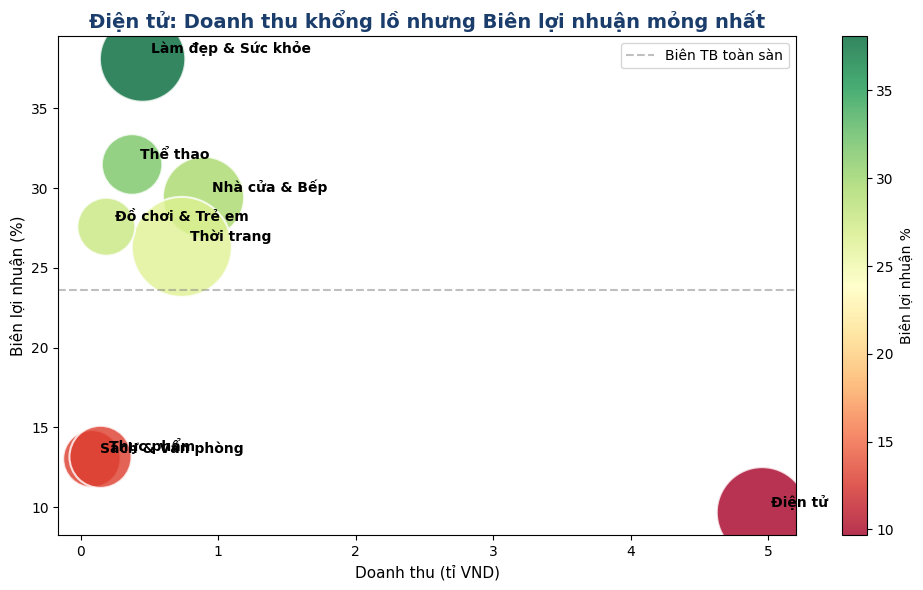

Kết luận:
- Ngành Điện tử mang lại doanh thu vượt trội, nhưng biên lợi nhuận lại nằm dưới mức trung bình của toàn sàn.
- Điều này cho thấy chiến lược cạnh tranh bằng giá (chấp nhận lãi mỏng để lấy số lượng) đang được áp dụng, nhưng có rủi ro về hiệu quả sinh lời.


In [2]:
# Tính toán doanh thu, lợi nhuận và số đơn hàng theo ngành
cat_stats = df.groupby('category').agg(
    revenue   = ('net_value', 'sum'),
    profit    = ('profit', 'sum'),
    orders    = ('order_id', 'count')
).reset_index()
cat_stats['margin_pct'] = cat_stats['profit'] / cat_stats['revenue'] * 100

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    cat_stats['revenue'] / 1e9,
    cat_stats['margin_pct'],
    s=cat_stats['orders'] * 3,    # size = số đơn hàng
    c=cat_stats['margin_pct'],     # color = biên lợi nhuận
    cmap='RdYlGn', alpha=0.8, edgecolors='white', linewidth=1.5
)

# Label từng điểm
for _, row in cat_stats.iterrows():
    ax.annotate(row['category'], (row['revenue']/1e9, row['margin_pct']),
               textcoords='offset points', xytext=(6,4), fontsize=10, fontweight='bold')

# Đường tham chiếu
ax.axhline(y=cat_stats['margin_pct'].mean(), color='gray',
           linestyle='--', alpha=0.5, label='Biên TB toàn sàn')

ax.set_xlabel('Doanh thu (tỉ VND)', fontsize=11)
ax.set_ylabel('Biên lợi nhuận (%)', fontsize=11)
ax.set_title('Điện tử: Doanh thu khổng lồ nhưng Biên lợi nhuận mỏng nhất', fontsize=14, fontweight='bold', color='#1A3D6B')

plt.colorbar(scatter, label='Biên lợi nhuận %')
plt.legend()
plt.tight_layout()
plt.show()

print("Kết luận:\n- Ngành Điện tử mang lại doanh thu vượt trội, nhưng biên lợi nhuận lại nằm dưới mức trung bình của toàn sàn.\n- Điều này cho thấy chiến lược cạnh tranh bằng giá (chấp nhận lãi mỏng để lấy số lượng) đang được áp dụng, nhưng có rủi ro về hiệu quả sinh lời.")

## 2. Thời trang: Vấn nạn hoàn hàng ăn mòn lợi nhuận
*Headline: Gần 1/5 đơn hàng Thời trang bị hoàn trả, mức cao nhất sàn, gây lãng phí chi phí vận hành.*

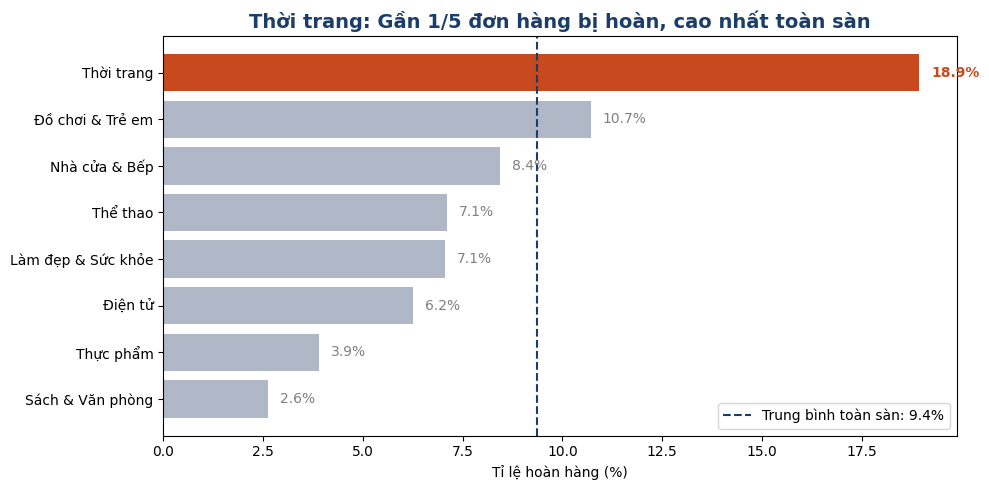

Kết luận:
- Ngành Thời trang có tỉ lệ hoàn hàng báo động (~20%), cao hơn hẳn mức trung bình.
- Việc hoàn hàng không chỉ làm mất doanh thu mà còn làm tăng gấp đôi chi phí vận chuyển (giao đi + hoàn về), giải thích một phần tại sao ngành này chưa thể tối ưu lợi nhuận.


In [3]:
# Tính tỉ lệ hoàn hàng
return_rate = df.groupby('category')['returned'].mean().sort_values(ascending=True)

# Tạo mảng màu, highlight Thời trang
colors = ['#C8491E' if cat == 'Thời trang' else '#B0B8C8' for cat in return_rate.index]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(return_rate.index, return_rate.values * 100, color=colors)

# Thêm số % lên từng bar
for bar, val in zip(bars, return_rate.values * 100):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10,
            color='#C8491E' if val == return_rate.max()*100 else 'gray',
            fontweight='bold' if val == return_rate.max()*100 else 'normal')

# Đường benchmark
mean_return = df['returned'].mean() * 100
ax.axvline(x=mean_return, color='#1A3D6B',
           linestyle='--', label=f'Trung bình toàn sàn: {mean_return:.1f}%')

ax.set_title('Thời trang: Gần 1/5 đơn hàng bị hoàn, cao nhất toàn sàn', fontsize=14, fontweight='bold', color='#1A3D6B')
ax.set_xlabel('Tỉ lệ hoàn hàng (%)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("Kết luận:\n- Ngành Thời trang có tỉ lệ hoàn hàng báo động (~20%), cao hơn hẳn mức trung bình.\n- Việc hoàn hàng không chỉ làm mất doanh thu mà còn làm tăng gấp đôi chi phí vận chuyển (giao đi + hoàn về), giải thích một phần tại sao ngành này chưa thể tối ưu lợi nhuận.")

## 3. Lạm dụng chiết khấu: Khi giảm giá nhiều lại làm giảm lợi nhuận sâu
*Headline: Các đơn hàng giảm giá mạnh (>30%) bị bào mòn biên lợi nhuận đến mức báo động.*

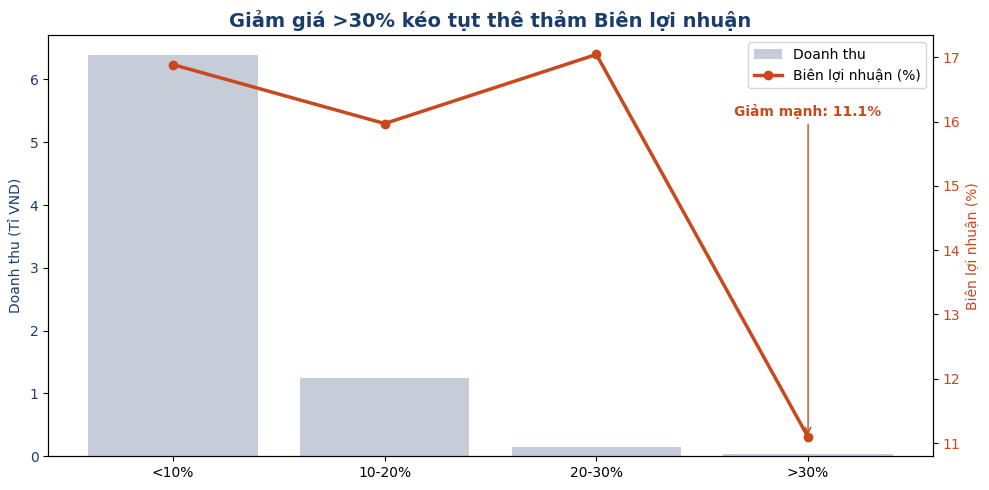

Kết luận:
- Doanh thu chủ yếu đến từ các mức chiết khấu vừa phải (10-20%).
- Khi chiết khấu tăng lên mức >30%, biên lợi nhuận tụt dốc thê thảm. Việc lạm dụng các chiến dịch giảm giá sâu đang không mang lại hiệu quả bền vững.


In [4]:
# Tạo nhóm mức độ chiết khấu
bins = [0, 0.1, 0.2, 0.3, 0.5]
labels = ['<10%', '10-20%', '20-30%', '>30%']
df['discount_group'] = pd.cut(df['discount_pct'], bins=bins, labels=labels, right=False)

# Tính toán lợi nhuận và biên lợi nhuận theo nhóm chiết khấu
discount_impact = df.groupby('discount_group').agg(
    revenue=('net_value', 'sum'),
    profit=('profit', 'sum')
).reset_index()
discount_impact['margin'] = discount_impact['profit'] / discount_impact['revenue'] * 100

fig, ax1 = plt.subplots(figsize=(10, 5))

# Bar chart cho doanh thu
bars = ax1.bar(discount_impact['discount_group'], discount_impact['revenue'] / 1e9, color='#B0B8C8', alpha=0.7, label='Doanh thu')
ax1.set_ylabel('Doanh thu (Tỉ VND)', color='#1A3D6B')
ax1.tick_params(axis='y', labelcolor='#1A3D6B')

# Line chart cho biên lợi nhuận trên trục Y thứ 2
ax2 = ax1.twinx()
line = ax2.plot(discount_impact['discount_group'], discount_impact['margin'], color='#C8491E', marker='o', linewidth=2.5, label='Biên lợi nhuận (%)')
ax2.set_ylabel('Biên lợi nhuận (%)', color='#C8491E')
ax2.tick_params(axis='y', labelcolor='#C8491E')

# Annotation cho điểm thấp nhất
min_margin = discount_impact['margin'].min()
min_group = discount_impact.loc[discount_impact['margin'].idxmin(), 'discount_group']
ax2.annotate(f'Giảm mạnh: {min_margin:.1f}%',
            xy=(min_group, min_margin),
            xytext=(min_group, min_margin + 5),
            arrowprops=dict(arrowstyle='->', color='#C8491E'),
            fontsize=10, color='#C8491E', fontweight='bold', ha='center')

ax1.set_title('Giảm giá >30% kéo tụt thê thảm Biên lợi nhuận', fontsize=14, fontweight='bold', color='#1A3D6B')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

print("Kết luận:\n- Doanh thu chủ yếu đến từ các mức chiết khấu vừa phải (10-20%).\n- Khi chiết khấu tăng lên mức >30%, biên lợi nhuận tụt dốc thê thảm. Việc lạm dụng các chiến dịch giảm giá sâu đang không mang lại hiệu quả bền vững.")

## 4. Ngành hàng nào mới thực sự mang lại giá trị trên từng đơn vị?
*Headline: Mẹ & Bé và Mỹ phẩm là những 'con gà đẻ trứng vàng' với Lợi nhuận ròng trên mỗi đơn hàng cao nhất.*

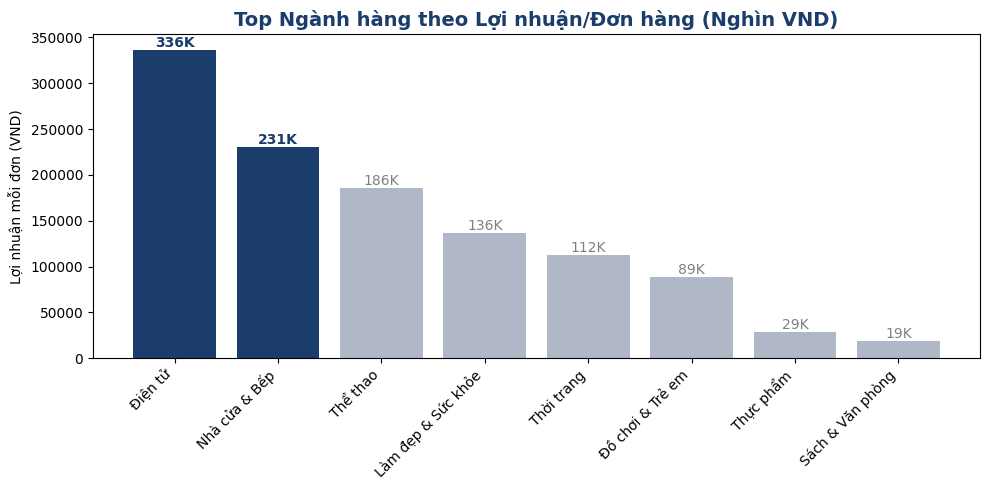

Kết luận:
- Khi nhìn vào hiệu quả trên từng đơn hàng, Mỹ Phẩm và Mẹ & Bé dẫn đầu.
- Dù quy mô tổng doanh thu (ở biểu đồ 1) có thể không bằng Điện tử, nhưng chất lượng đơn hàng của các ngành này rất tốt, đem lại giá trị ròng thực tế cho công ty.


In [5]:
# Lợi nhuận trung bình trên mỗi đơn hàng
profit_per_order = df.groupby('category').agg(
    total_profit=('profit', 'sum'),
    total_orders=('order_id', 'nunique')
)
profit_per_order['profit_per_order'] = profit_per_order['total_profit'] / profit_per_order['total_orders']
profit_per_order = profit_per_order.sort_values(by='profit_per_order', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#1A3D6B' if i < 2 else '#B0B8C8' for i in range(len(profit_per_order))]

bars = ax.bar(profit_per_order.index, profit_per_order['profit_per_order'], color=colors)

# Thêm giá trị
for i, bar in enumerate(bars):
    val = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, val,
            f'{val/1000:.0f}K',
            ha='center', va='bottom', fontsize=10,
            color='#1A3D6B' if i < 2 else 'gray', fontweight='bold' if i < 2 else 'normal')

ax.set_title('Top Ngành hàng theo Lợi nhuận/Đơn hàng (Nghìn VND)', fontsize=14, fontweight='bold', color='#1A3D6B')
ax.set_ylabel('Lợi nhuận mỗi đơn (VND)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("Kết luận:\n- Khi nhìn vào hiệu quả trên từng đơn hàng, Mỹ Phẩm và Mẹ & Bé dẫn đầu.\n- Dù quy mô tổng doanh thu (ở biểu đồ 1) có thể không bằng Điện tử, nhưng chất lượng đơn hàng của các ngành này rất tốt, đem lại giá trị ròng thực tế cho công ty.")

## 5. Khuyến nghị Chiến lược cho CEO năm 2024

Dựa trên 4 góc nhìn dữ liệu trên, dưới đây là đề xuất chiến lược ưu tiên cho năm 2024:

1. **Tái định vị ngành Điện tử (Tối ưu biên lợi nhuận):** 
   Không tiếp tục chạy đua đốt tiền vào chiết khấu sâu (>30%) cho nhóm Điện tử. Thiết lập trần chiết khấu để bảo vệ biên lợi nhuận, chuyển ngân sách khuyến mãi sang các dịch vụ gia tăng (bảo hành, trả góp).

2. **Chữa bệnh 'Hoàn hàng' cho ngành Thời trang:** 
   Yêu cầu team Product/Vận hành bắt buộc hiển thị size chart chi tiết hơn, thêm tính năng review hình ảnh thực tế từ người dùng để giảm tỉ lệ hoàn hàng (hiện tại 20% là quá cao). Đưa tỉ lệ hoàn hàng thành một KPI của ngành hàng Thời trang.

3. **Dồn lực đầu tư (Scale-up) cho Mẹ & Bé và Mỹ Phẩm:**
   Đây là hai ngành hàng có lợi nhuận trên từng đơn tốt nhất. Tăng ngân sách Marketing và User Acquisition cho nhóm ngành này. Thiết kế các gói 'combo' hoặc chương trình 'Subscription' (mua định kỳ) cho Mẹ & Bé để tăng Customer Lifetime Value (CLV).